# Netflix Content Analysis: In-Depth EDA

**Project Objective:** Perform a comprehensive exploratory data analysis of the Netflix dataset.  
We explore trends in content production, identify popular genres, analyze ratings, understand the  
distribution of Movies vs. TV Shows, and uncover deeper strategic patterns.

---

## Step 1: Setup — Importing Libraries

Importing our core data-science and visualization toolkit.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Consistent plot style
sns.set_style('darkgrid')

## Step 2: Data Loading & Initial Inspection

Load `netflix_titles.csv` and get a high-level overview of its structure.

In [2]:
# !git clone "https://github.com/GeeksforgeeksDS/21-Days-21-Projects-Dataset"

In [3]:
netflix_df = pd.read_csv('netflix_titles.csv')
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [4]:
netflix_df.shape

(7787, 12)

In [5]:
# Concise structural summary
netflix_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   str  
 10  listed_in     7787 non-null   str  
 11  description   7787 non-null   str  
dtypes: int64(1), str(11)
memory usage: 730.2 KB


**Interpretation of `.info()`:**
- **7787 entries** (titles) across 12 columns.
- **Key issue:** `date_added` is `object` (string) — must be converted to `datetime` for time-series analysis.
- **Missing values:** `director`, `cast`, `country`, `date_added`, and `rating` all contain nulls; `director` is the most affected.

## Step 3: Data Cleaning & Transformation

Handling missing values and correcting data types before any analysis.

In [6]:
# 1. Fill missing 'director' and 'cast' with 'Unknown'
netflix_df['director'] = netflix_df['director'].fillna('Unknown')
netflix_df['cast']     = netflix_df['cast'].fillna('Unknown')

In [7]:
# 2. Fill missing 'country' with the mode (most common country)
mode_country = netflix_df['country'].mode()[0]
netflix_df['country'] = netflix_df['country'].fillna(mode_country)

In [8]:
# 3. Drop the few rows where 'date_added' or 'rating' is missing
#    (<0.2% of data — safe to discard)
netflix_df.dropna(subset=['date_added', 'rating'], inplace=True)

In [9]:
# 4. Convert 'date_added' to datetime
#    format='mixed' handles varied date-string formats
#    dayfirst=False → ambiguous dates treated as MM/DD
netflix_df['date_added'] = pd.to_datetime(netflix_df['date_added'], format='mixed', dayfirst=False)

**Notes on `pd.to_datetime` arguments:**
- **`format='mixed'`** — infers the date format automatically, useful when strings aren't uniformly formatted.
- **`dayfirst=False`** — ambiguous dates (e.g., `01/02/2023`) are interpreted as January 2nd (month-first).

In [10]:
# 5. Engineer year and month features from 'date_added'
netflix_df['year_added']  = netflix_df['date_added'].dt.year
netflix_df['month_added'] = netflix_df['date_added'].dt.month

In [11]:
# Verify: confirm zero nulls and correct dtypes
print("Missing values after cleaning:")
print(netflix_df.isnull().sum())
print("\nData types after transformation:")
print(netflix_df.dtypes)

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

Data types after transformation:
show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
year_added               int32
month_added              int32
dtype: object


## Step 4: Exploratory Data Analysis & Visualization

### 4.1 What is the distribution of content type?

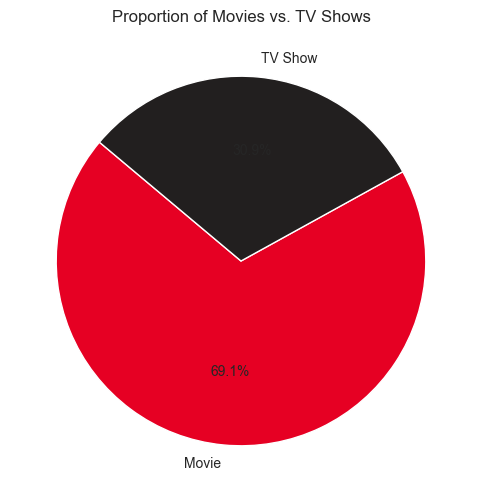

In [12]:
plt.figure(figsize=(8, 6))
type_counts = netflix_df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        startangle=140, colors=['#e60023', '#221f1f'])
plt.title('Proportion of Movies vs. TV Shows')
plt.ylabel('')
plt.show()

**Insight:** Netflix's library is movie-heavy — roughly **70% Movies** vs. 30% TV Shows.

### 4.2 How has content been added over time?

<Figure size 1400x800 with 0 Axes>

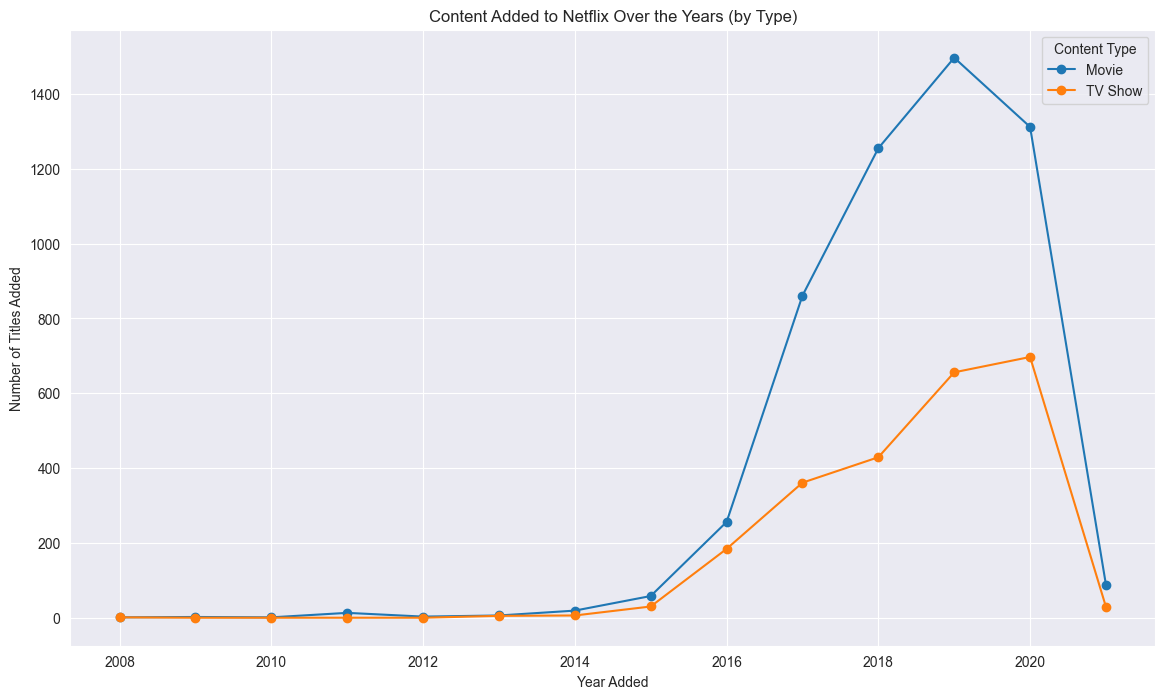

In [13]:
content_over_time = netflix_df.groupby(['year_added', 'type']).size().unstack().fillna(0)

plt.figure(figsize=(14, 8))
content_over_time.plot(kind='line', marker='o', figsize=(14, 8))
plt.title('Content Added to Netflix Over the Years (by Type)')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.legend(title='Content Type')
plt.grid(True)
plt.show()

**Insight:** Both Movies and TV Shows grew significantly, but movie additions accelerated much more dramatically, peaking around 2019.  
TV-show growth was steadier. A slight dip in 2020-2021 may reflect COVID-19 production disruptions or data incompleteness.

### 4.3 What are the most popular genres?

In [14]:
# Explode multi-genre 'listed_in' column so each row = one genre
genres = netflix_df.assign(genre=netflix_df['listed_in'].str.split(', ')).explode('genre')

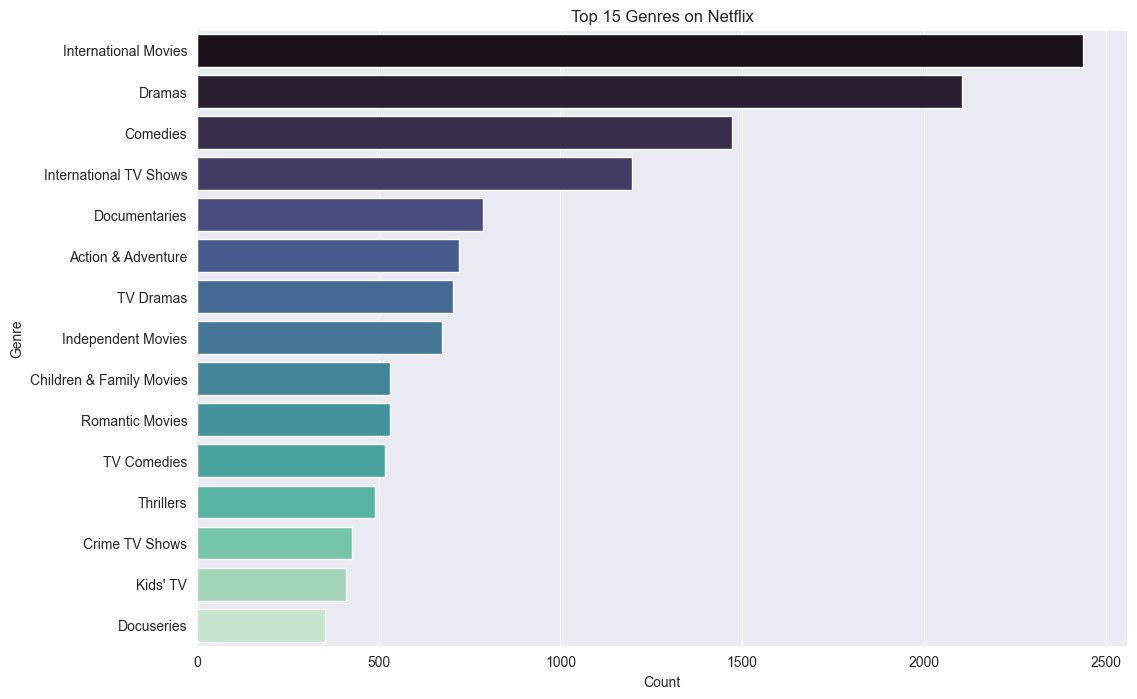

In [15]:
top_genres_counts = genres['genre'].value_counts().reset_index()
top_genres_counts.columns = ['genre', 'count']

plt.figure(figsize=(12, 8))
sns.barplot(y='genre', x='count', data=top_genres_counts.head(15),
            palette='mako', hue='genre', legend=False)
plt.title('Top 15 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

**Insight:** "International Movies" is the most common tag — a direct signal of Netflix's global content strategy.  
It's closely followed by Dramas, Comedies, and Action & Adventure.

### 4.4 What is the distribution of content duration?

In [16]:
# Separate Movies and TV Shows for separate duration treatment
movies_df   = netflix_df[netflix_df['type'] == 'Movie'].copy()
tv_shows_df = netflix_df[netflix_df['type'] == 'TV Show'].copy()

# Parse numeric duration
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(int)
tv_shows_df['seasons']    = tv_shows_df['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(int)

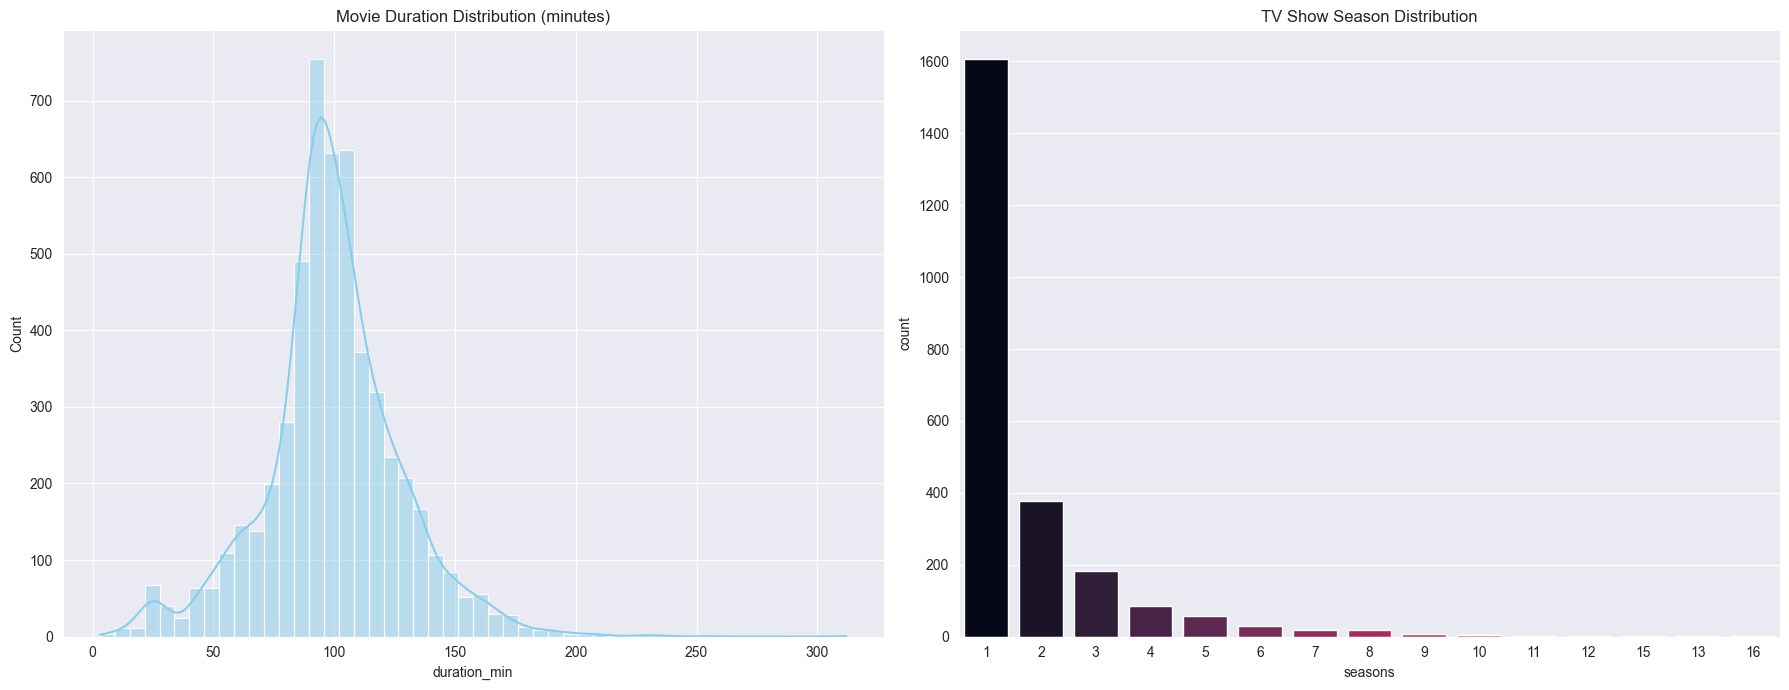

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.histplot(ax=axes[0], data=movies_df, x='duration_min', bins=50, kde=True,
             color='skyblue').set_title('Movie Duration Distribution (minutes)')

sns.countplot(ax=axes[1], x='seasons', data=tv_shows_df, palette='rocket',
              order=tv_shows_df['seasons'].value_counts().index,
              hue='seasons', legend=False).set_title('TV Show Season Distribution')

plt.tight_layout()
plt.show()

**Insight:**
- Most movies run **80–120 minutes** — standard feature-film length.
- The vast majority of TV shows have only **1 season**, suggesting Netflix produces many limited series or pilots and only renews the most successful ones.

### 4.5 Where does the content come from? (Geographical Analysis)

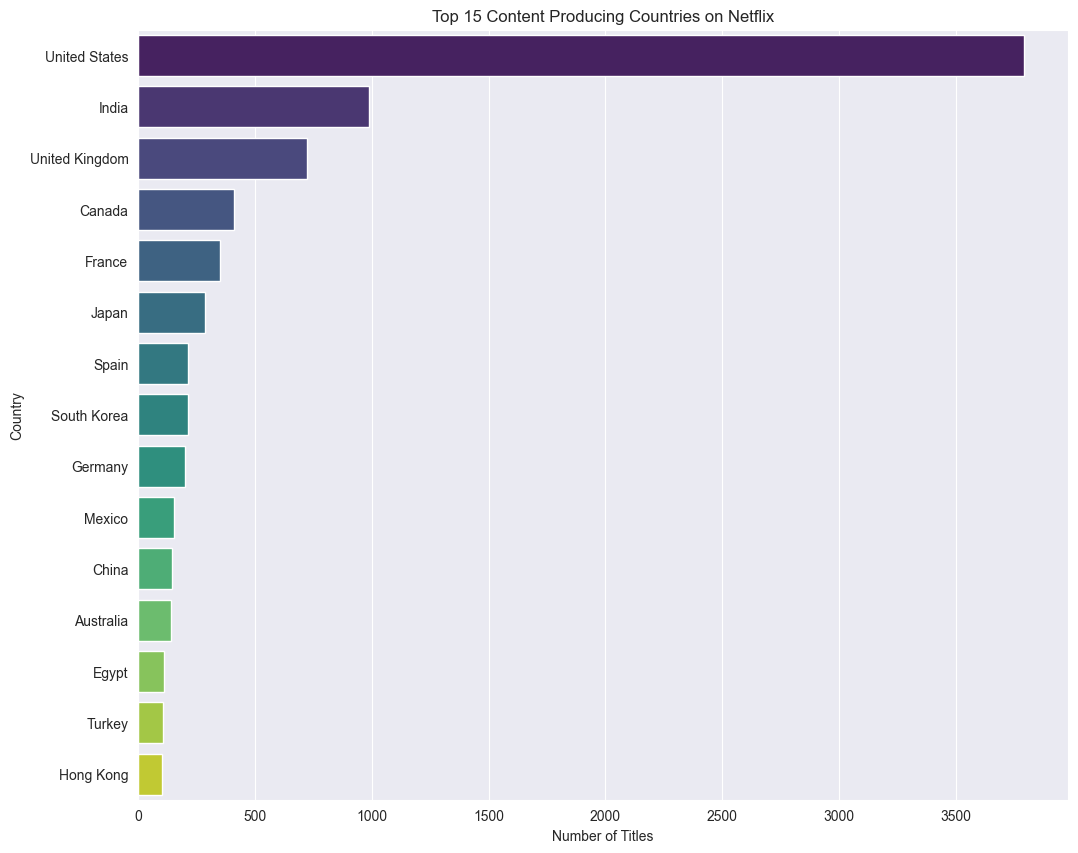

In [18]:
# Explode multi-country entries
countries = netflix_df.assign(country=netflix_df['country'].str.split(', ')).explode('country')

top_countries_counts = countries['country'].value_counts().reset_index()
top_countries_counts.columns = ['country', 'count']

plt.figure(figsize=(12, 10))
sns.barplot(y='country', x='count', data=top_countries_counts.head(15),
            palette='viridis', hue='country', legend=False)
plt.title('Top 15 Content Producing Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

**Insight:** The **United States** is by far the top content producer, but **India** is a strong second.  
The UK, Japan, and South Korea also rank highly, underscoring Netflix's global, multi-market content strategy.

### 4.6 What are the maturity ratings of the content?

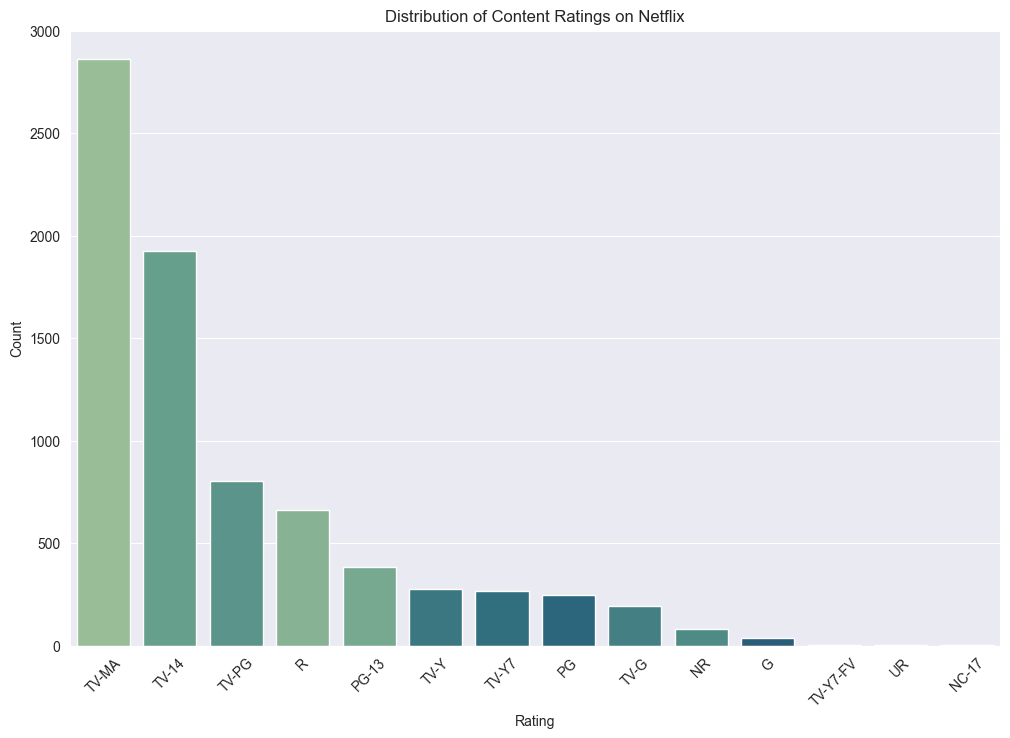

In [19]:
plt.figure(figsize=(12, 8))
sns.countplot(x='rating', data=netflix_df,
              order=netflix_df['rating'].value_counts().index,
              palette='crest', hue='rating', legend=False)
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Insight:** Netflix's library skews heavily towards mature audiences — `TV-MA` and `TV-14` dominate.  
Family-friendly ratings like `TV-G` and `TV-Y` are comparatively rare.

## Step 5: Feature Engineering — Content Freshness

Creating `age_on_netflix` to measure how old a title was when added.  
This reveals whether Netflix favours **new originals** (age ≈ 0) or **licensed back-catalogues** (age >> 0).

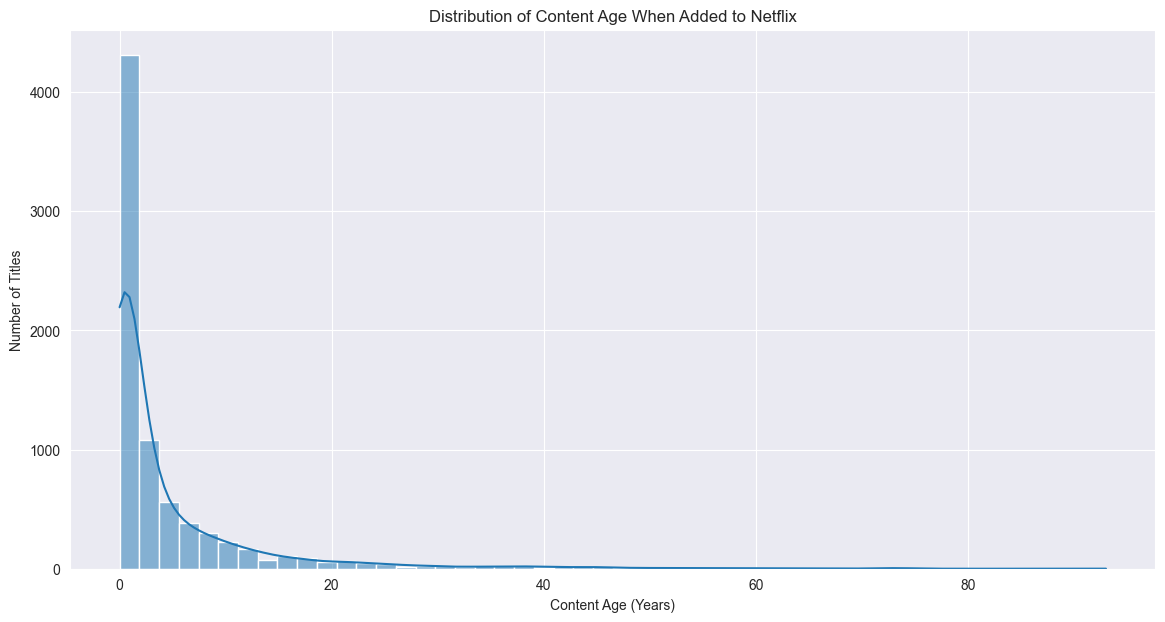

In [20]:
netflix_df['age_on_netflix'] = netflix_df['year_added'] - netflix_df['release_year']

# Filter out impossible negative values (data errors)
content_age = netflix_df[netflix_df['age_on_netflix'] >= 0]

plt.figure(figsize=(14, 7))
sns.histplot(data=content_age, x='age_on_netflix', bins=50, kde=True)
plt.title('Distribution of Content Age When Added to Netflix')
plt.xlabel('Content Age (Years)')
plt.ylabel('Number of Titles')
plt.show()

**Insight:** The large spike at **age = 0** reflects Netflix Originals — titles released directly on the platform.  
The long right tail shows Netflix also maintains a rich back-catalogue of licensed content spanning decades.

## Step 6: Deeper Multivariate Analysis

Examining how movie duration varies across the top 5 genres.

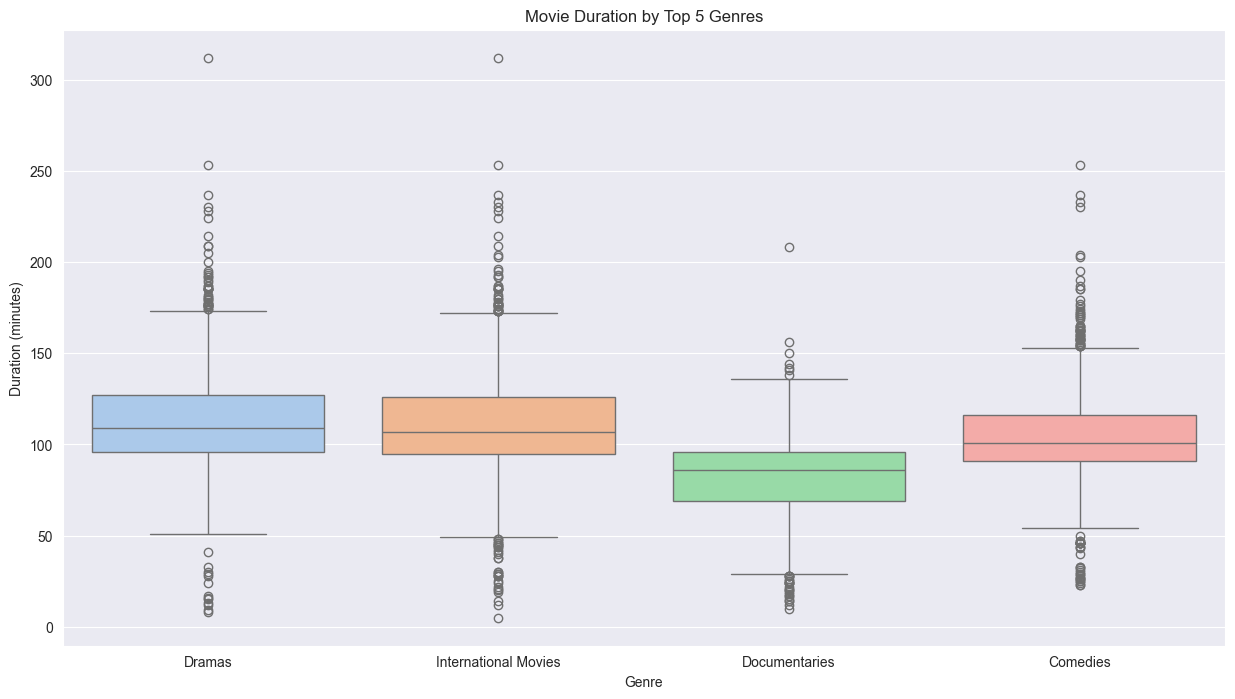

In [21]:
top_genres_list = genres['genre'].value_counts().index[:5]
genres_movies   = genres[(genres['type'] == 'Movie') & (genres['genre'].isin(top_genres_list))].copy()
genres_movies['duration_min'] = genres_movies['duration'].str.replace(' min', '').astype(int)

plt.figure(figsize=(15, 8))
sns.boxplot(data=genres_movies, x='genre', y='duration_min',
            palette='pastel', hue='genre', legend=False)
plt.title('Movie Duration by Top 5 Genres')
plt.xlabel('Genre')
plt.ylabel('Duration (minutes)')
plt.show()

**Insight:** Median runtime is broadly similar (~90–100 min) across top genres.  
Dramas show a wider spread with many longer films. International Movies also show high variance,  
reflecting diverse filmmaking conventions around the world.

## Step 7: Word Cloud — Content Description Themes

Generating a word cloud from the `description` column to surface the most common narrative themes.

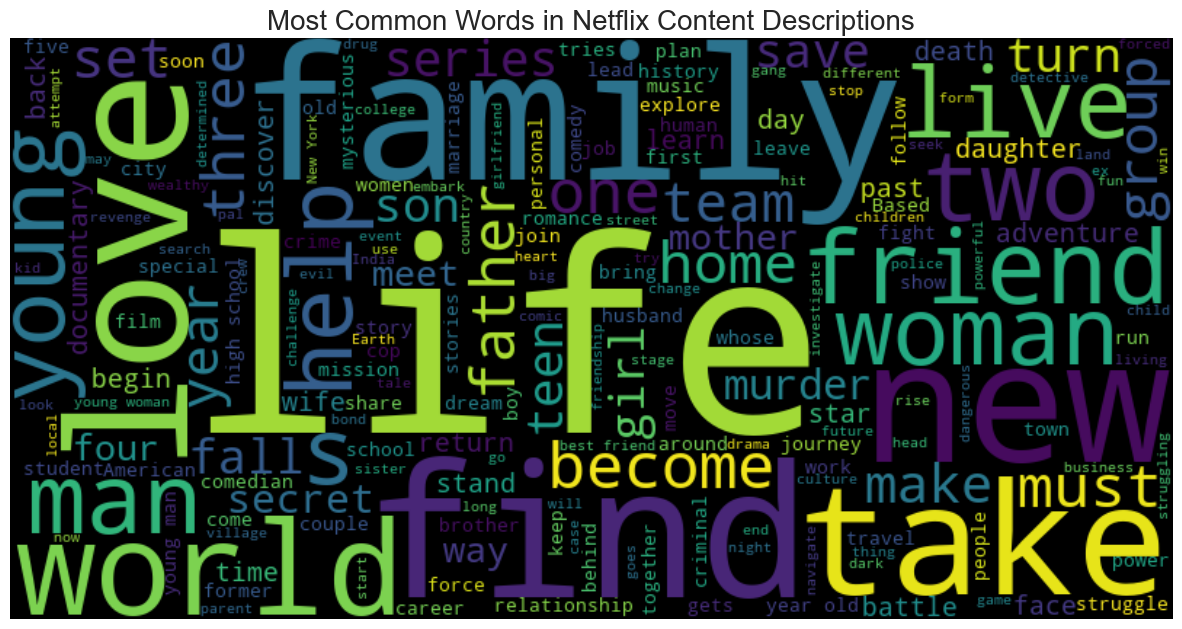

In [22]:
text = ' '.join(netflix_df['description'])
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Netflix Content Descriptions', fontsize=20)
plt.show()

**Insight:** Dominant words — *life*, *family*, *love*, *young*, *friends*, *world* — point to universal human themes.  
Action words (*find*, *series*, *new*) suggest adventure and discovery are also recurring narrative hooks.

---
## Step 8: Advanced Analysis — Deeper Strategic Questions

Five targeted investigations that build on the core EDA to surface additional strategic insights.

### 8.1 How has the distribution of content ratings changed over time?

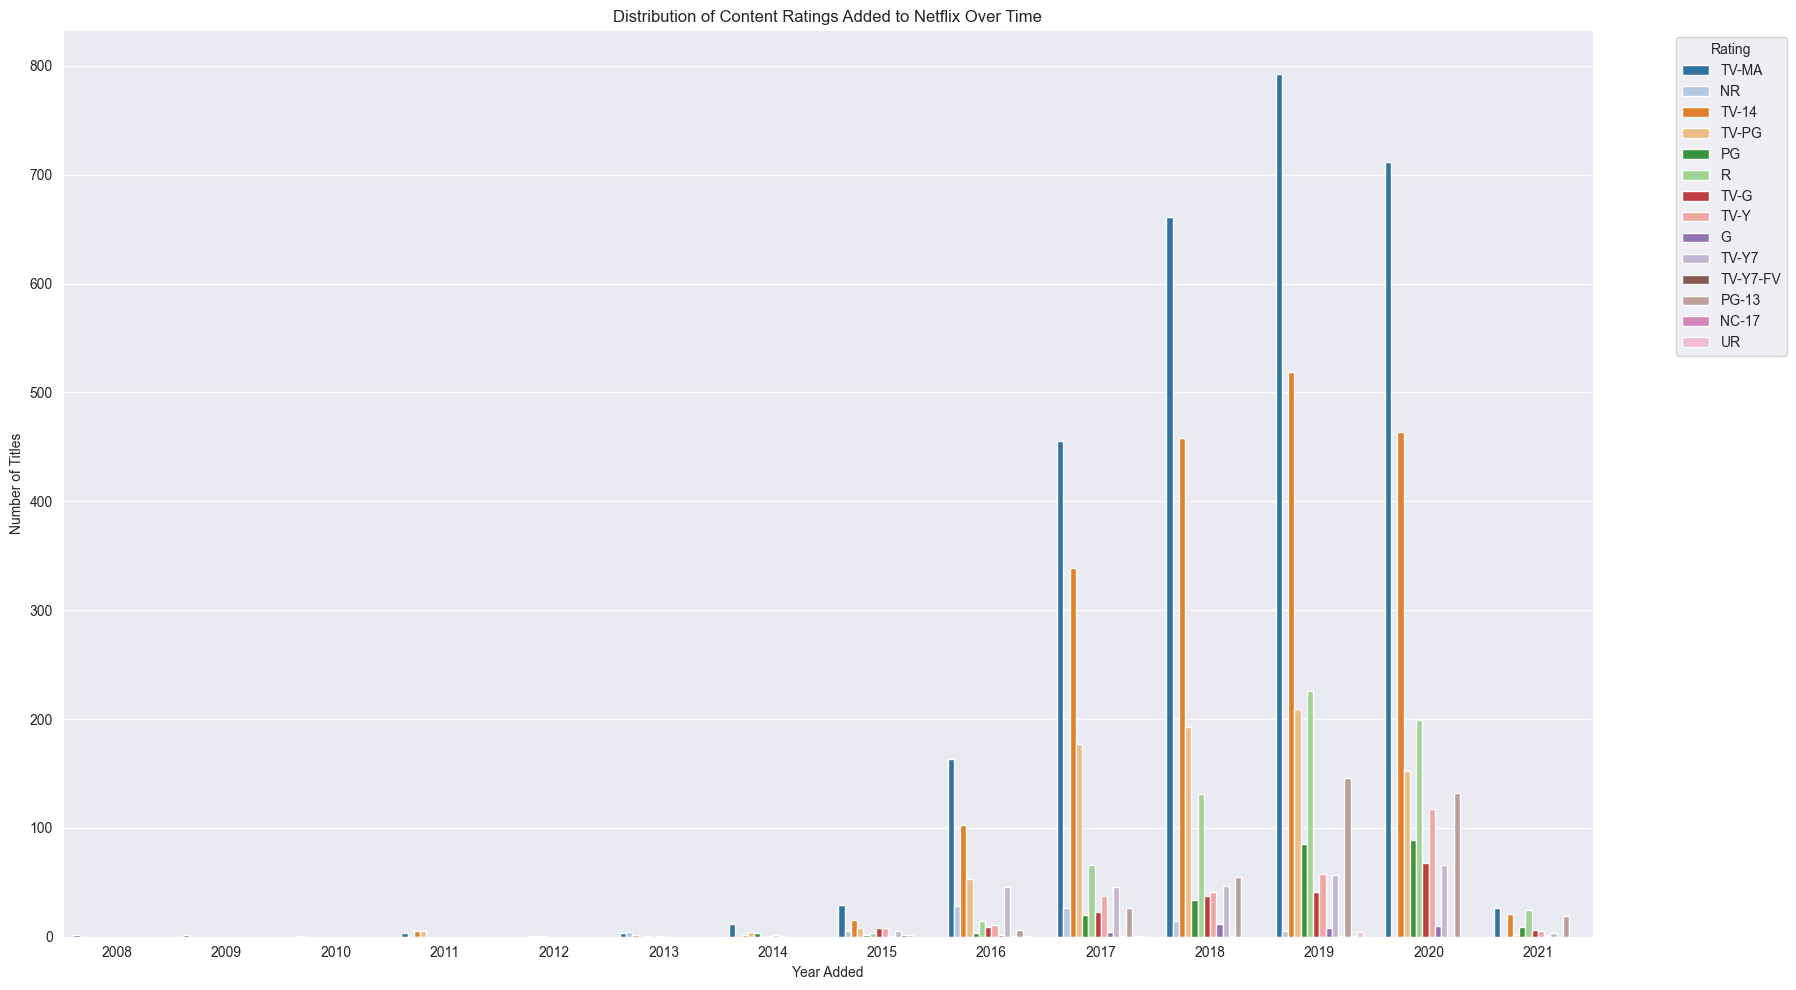

In [23]:
plt.figure(figsize=(18, 10))
sns.countplot(data=netflix_df, x='year_added', hue='rating',
              order=sorted(netflix_df['year_added'].dropna().unique()), palette='tab20')
plt.title('Distribution of Content Ratings Added to Netflix Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

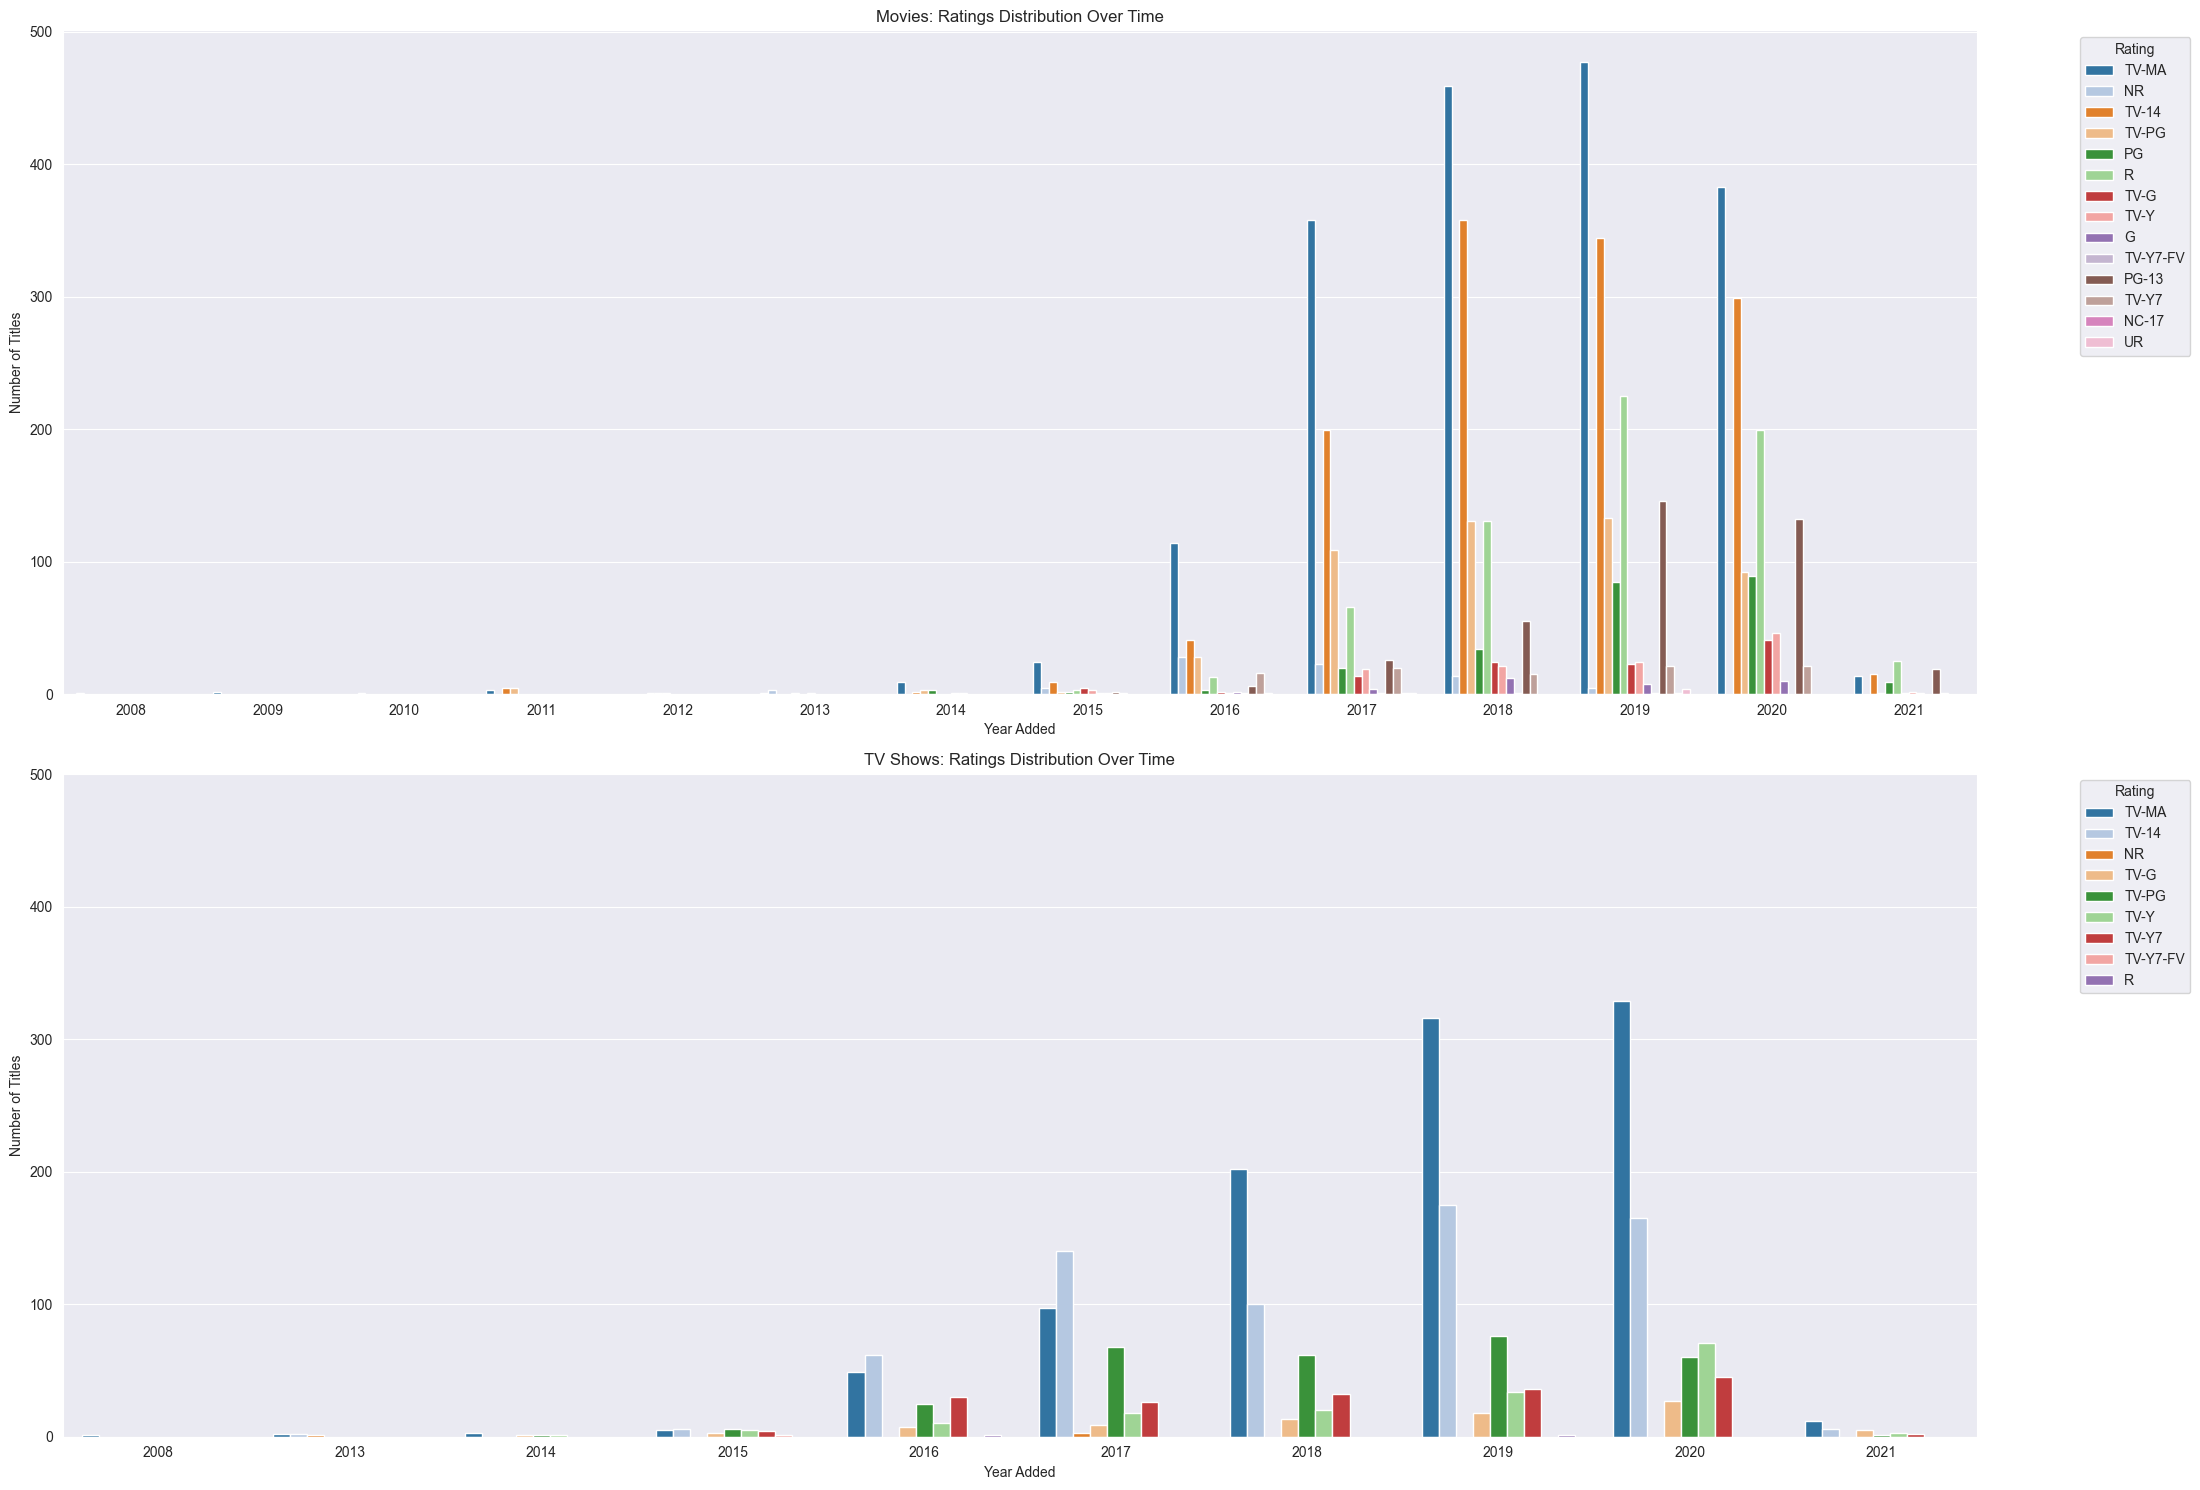

In [24]:
# Split by content type for sharper comparison
fig, axes = plt.subplots(2, 1, figsize=(22, 15), sharey=True)

sns.countplot(data=movies_df, x='year_added', hue='rating',
              order=sorted(movies_df['year_added'].dropna().unique()),
              palette='tab20', ax=axes[0])
axes[0].set_title('Movies: Ratings Distribution Over Time')
axes[0].set_xlabel('Year Added')
axes[0].set_ylabel('Number of Titles')
axes[0].legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.countplot(data=tv_shows_df, x='year_added', hue='rating',
              order=sorted(tv_shows_df['year_added'].dropna().unique()),
              palette='tab20', ax=axes[1])
axes[1].set_title('TV Shows: Ratings Distribution Over Time')
axes[1].set_xlabel('Year Added')
axes[1].set_ylabel('Number of Titles')
axes[1].legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [25]:
# Curiosity check: any TV Shows rated 'R'?
tv_shows_r = tv_shows_df[tv_shows_df['rating'] == 'R']
print(f"TV Shows with an 'R' rating: {len(tv_shows_r)}")
tv_shows_r

TV Shows with an 'R' rating: 2


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,seasons
4497,s4498,TV Show,Nobel,Unknown,"Aksel Hennie, Tuva Novotny, Anders Danielsen L...",Norway,2016-12-10,2016,R,1 Season,"International TV Shows, TV Dramas, TV Thrillers",A series of incidents in Afghanistan set compl...,2016,12,1
6435,s6436,TV Show,The Hateful Eight: Extended Version,Quentin Tarantino,"Samuel L. Jackson, Kurt Russell, Jennifer Jaso...",United States,2019-04-25,2015,R,1 Season,TV Shows,Trapped at a stagecoach stop as a storm rages ...,2019,4,1


**Findings:**
- `TV-MA` (Mature Audience) content has grown consistently year-over-year.
- For most years, Netflix added more `TV-MA` movies than any other rating category.
- TV Shows showed relatively more `TV-14` content during 2015–2017 before `TV-MA` took over.
- Only **two TV series** carry an `R` rating (2015 and 2016) — a rare crossover from film rating conventions.

### 8.2 Is there a relationship between content age and content type?

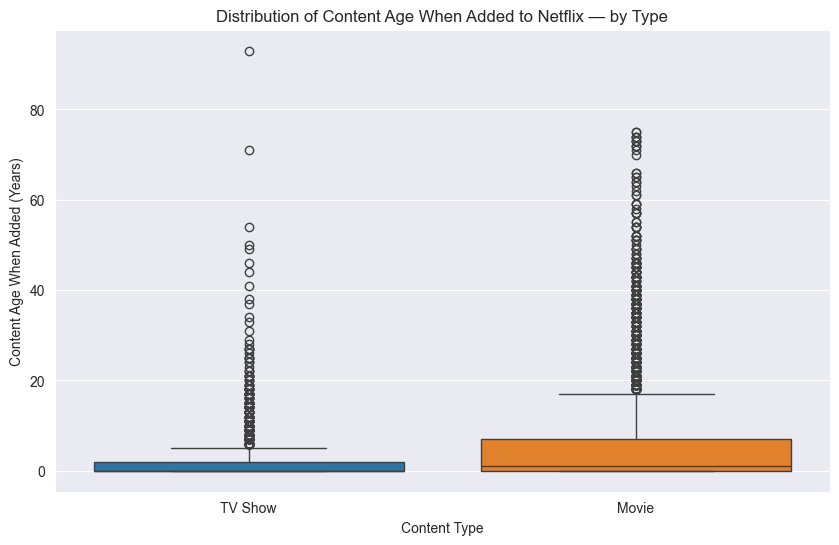

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=content_age, x='type', y='age_on_netflix', hue='type', legend=False)
plt.title('Distribution of Content Age When Added to Netflix — by Type')
plt.xlabel('Content Type')
plt.ylabel('Content Age When Added (Years)')
plt.show()

**Findings:**
- Both types skew towards recent content (age 0–10 years), confirming Netflix's preference for freshness.
- **Movies** have a wider age range (0–10 years typical) and more high-age outliers — Netflix licences older films liberally.
- **TV Shows** are typically newer when added (0–5 years) and fewer extreme outliers, though the oldest outlier exceeds 80 years!
- Netflix is more likely to acquire an old movie than an old TV series.

### 8.3 Release Year vs. Year Added — Content Production Trends

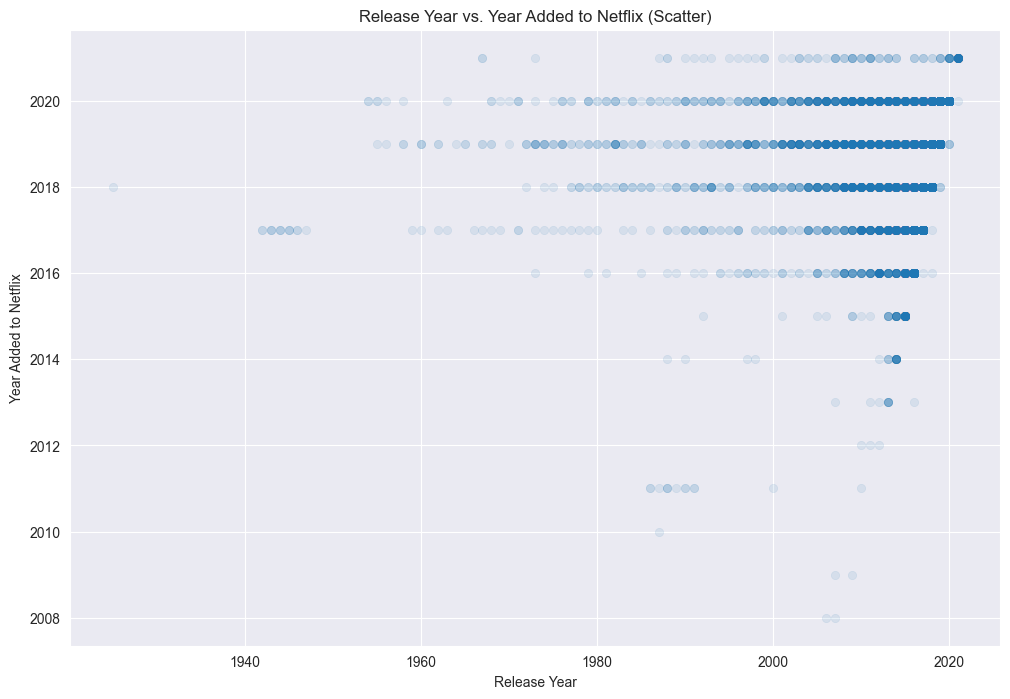

In [27]:
# Scatter — useful for seeing individual spread
plt.figure(figsize=(12, 8))
sns.scatterplot(data=netflix_df, x='release_year', y='year_added', alpha=0.1, edgecolor=None)
plt.xlabel('Release Year')
plt.ylabel('Year Added to Netflix')
plt.title('Release Year vs. Year Added to Netflix (Scatter)')
plt.show()

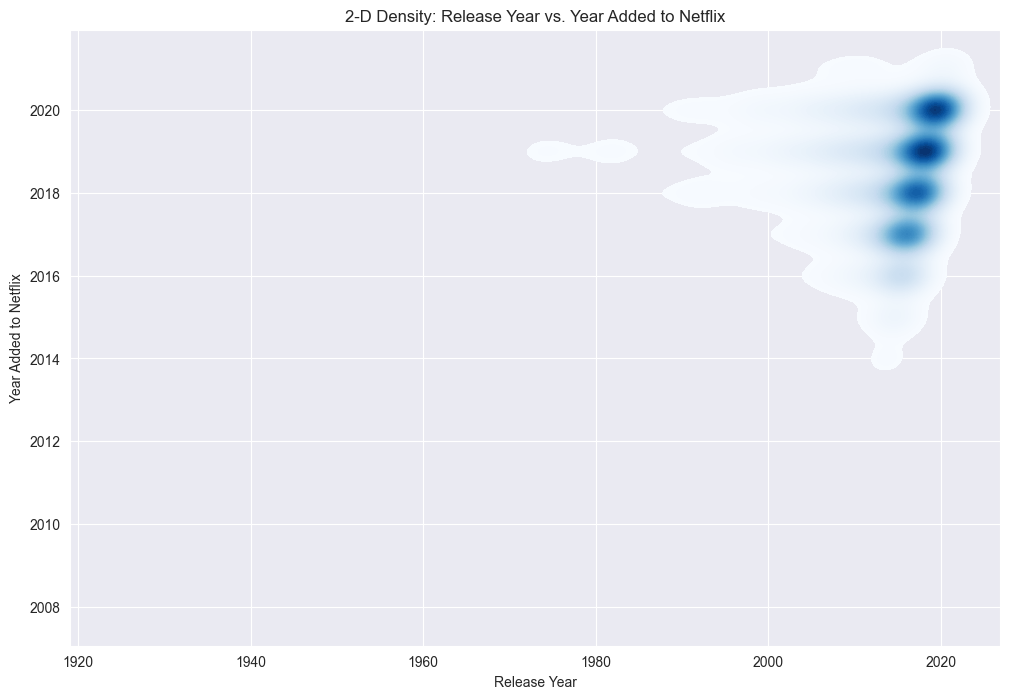

In [28]:
# 2-D KDE — clearer density picture
plt.figure(figsize=(12, 8))
sns.kdeplot(data=netflix_df, x='release_year', y='year_added',
            fill=True, cmap='Blues', thresh=0.05, levels=100)
plt.xlabel('Release Year')
plt.ylabel('Year Added to Netflix')
plt.title('2-D Density: Release Year vs. Year Added to Netflix')
plt.show()

**Findings:**
- The density is concentrated along the diagonal — most content is added shortly after its release.
- The densest cluster centres around release years 2015–2020 added in 2018–2020.
- Netflix increased acquisitions of **older content** (wide release year spread) between 2018 and 2020,  
  likely as part of a library-building strategy during its high-growth phase.

### 8.4 What are the most common word pairs (bigrams) in content descriptions?

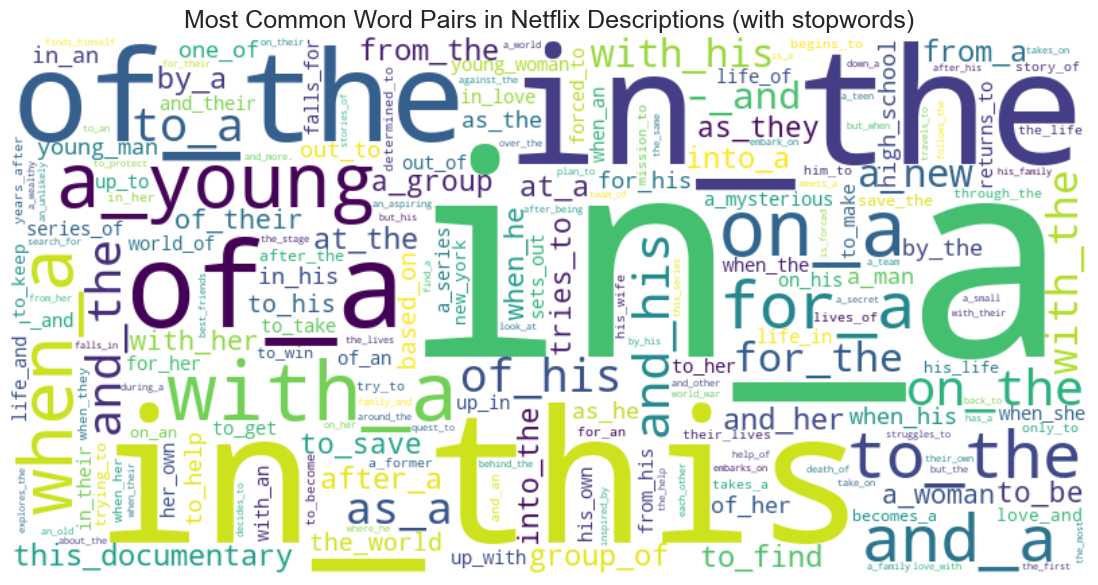

In [29]:
from collections import Counter

# Raw bigrams (no stopword removal)
all_words = ' '.join(netflix_df['description'].dropna()).lower().split()
bigrams_raw = ['_'.join([all_words[i], all_words[i+1]]) for i in range(len(all_words)-1)]
bigram_counts_raw = Counter(bigrams_raw)

bigram_wc_raw = WordCloud(width=800, height=400, background_color='white')    .generate_from_frequencies(bigram_counts_raw)

plt.figure(figsize=(15, 7))
plt.imshow(bigram_wc_raw, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Word Pairs in Netflix Descriptions (with stopwords)', fontsize=18)
plt.show()

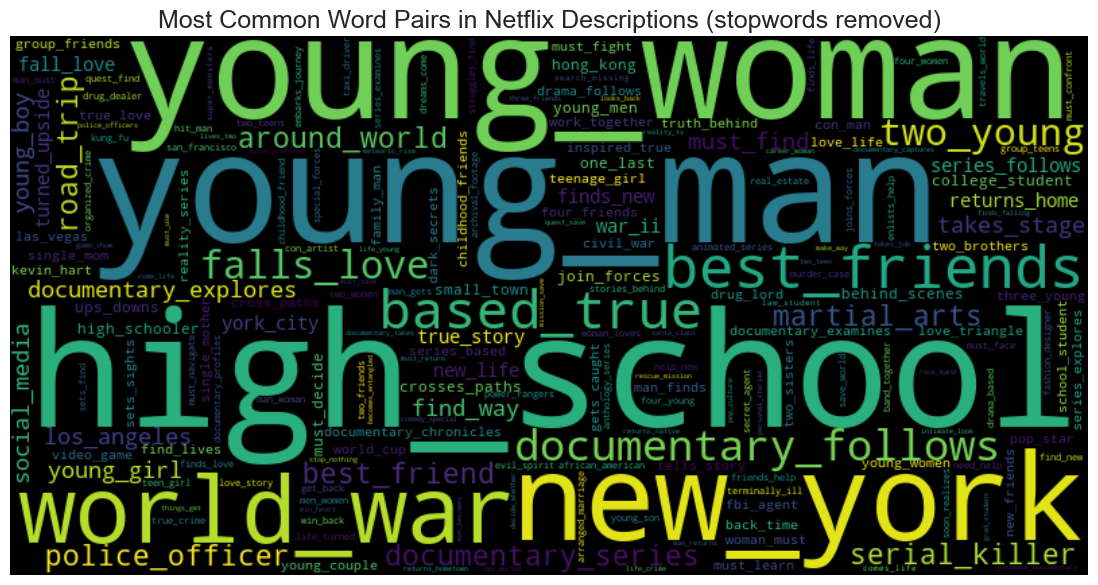

In [31]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Filter stopwords and non-alpha tokens, then rebuild bigrams
filtered_words = [w for w in all_words if w.isalpha() and w not in stop_words]
bigrams_clean = ['_'.join([filtered_words[i], filtered_words[i+1]])
                 for i in range(len(filtered_words)-1)]
bigram_counts_clean = Counter(bigrams_clean)

bigram_wc_clean = WordCloud(width=800, height=400, background_color='black')    .generate_from_frequencies(bigram_counts_clean)

plt.figure(figsize=(15, 7))
plt.imshow(bigram_wc_clean, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Word Pairs in Netflix Descriptions (stopwords removed)', fontsize=18)
plt.show()

**Findings:**
- After removing stopwords, **"high school"** is the dominant bigram — teen coming-of-age content is extremely prevalent.
- **"young man"** / **"young woman"** follow closely, reinforcing the focus on youth narratives.
- Geographic and cultural references (**"New York"**, **"world war"**) and format indicators (**"documentary series"**) also appear prominently.
- This reflects Netflix's strategy of combining broad appeal (family, friendship, love) with culturally specific storytelling.

### 8.5 Who are the top directors on Netflix?

In [32]:
top_directors = (
    netflix_df[netflix_df['director'] != 'Unknown']['director']
    .value_counts()
    .head(20)
    .reset_index()
)
top_directors.columns = ['Director', 'Number of Titles']
top_directors

,Director,Number of Titles
0,"Raúl Campos, Jan Suter",18
1,Marcus Raboy,16
2,Jay Karas,14
3,Cathy Garcia-Molina,13
4,Youssef Chahine,12
5,Martin Scorsese,12
6,Jay Chapman,12
7,Steven Spielberg,10
8,David Dhawan,9
9,Kunle Afolayan,8


In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(y='Director', x='Number of Titles', data=top_directors,
            palette='flare', hue='Director', legend=False)
plt.title('Top 20 Directors on Netflix by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.tight_layout()
plt.show()

**Findings:**
- **Raúl Campos & Jan Suter** top the list (they frequently co-direct and specialise in Latin American comedy content).
- **Marcus Raboy** and **Jay Karas** follow closely — both prolific in comedy stand-up specials.
- The top directors skew heavily towards stand-up comedy and documentary formats, genres that are fast and inexpensive to produce at volume.

---
## Step 9: Final Conclusion & Summary of Insights

This end-to-end EDA of the Netflix dataset has uncovered several key patterns about the platform's content library and strategic positioning.

### Key Findings

| # | Theme | Finding |
|---|-------|---------|
| 1 | **Content Mix** | ~70% Movies, 30% TV Shows; movie additions grew explosively 2016–2019 |
| 2 | **Global Strategy** | US leads production, but India is a powerful #2; "International Movies" is the top genre tag |
| 3 | **Audience Targeting** | Library skews heavily mature (`TV-MA` dominant); children's content is a small fraction |
| 4 | **Content Freshness** | Spike at age=0 signals strong Netflix Originals pipeline; long tail shows deep licensed back-catalogue |
| 5 | **Format Norms** | Movies: 80–120 min; TV Shows: mostly 1 season (limited series model) |
| 6 | **Ratings Over Time** | `TV-MA` share has grown year-on-year, doubling down on the adult audience strategy |
| 7 | **Narrative Themes** | Bigram analysis surfaces "high school", "young man/woman", "new york" — youth & urban themes dominate |
| 8 | **Director Patterns** | Volume leaders are stand-up comedy and documentary directors — low-cost, high-output formats |

### Limitations
- This dataset is a **snapshot in time** and does not reflect the current Netflix catalogue.
- **No viewership data** — we analysed the *supply* of content, not audience *demand* or engagement.
- Multi-valued fields (countries, genres) were exploded for counting, which can inflate totals for co-productions.

### Next Steps
- Enrich with IMDb ratings or Rotten Tomatoes scores to correlate content quality with catalogue strategy.
- Time-series modelling to forecast content addition trends.
- NLP sentiment analysis on descriptions to map emotional tone by genre.